<a href="https://colab.research.google.com/github/Deb052024/Machine-Prediction/blob/main/Telco_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import datetime as dt

In [ ]:
df=pd.read_excel('/content/telcom_data.xlsx')

In [ ]:
df.iloc[0:5,0:15]

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,42.0,5.0,23.0,44.0,NaN
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,65.0,5.0,16.0,26.0,NaN
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,NaN,NaN,6.0,9.0,NaN
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,NaN,NaN,44.0,44.0,NaN
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,NaN,NaN,6.0,9.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[ns]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[ns]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  float64       
 7   MSISDN/Number                             148935 non-null  float64       
 8   IMEI                                      149429 non-null  float64       
 9   Last Location N

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Start,150000,2019-04-26 12:36:38.953740032,2019-04-04 12:01:18,2019-04-25 00:26:00.750000128,2019-04-26 08:51:24.500000,2019-04-27 18:18:59.750000128,2019-04-29 07:28:43,NaN
Start ms,150000.0,499.1882,0.0,250.0,499.0,749.0,999.0,288.611834
End,150000,2019-04-27 17:40:08.059673344,2019-04-24 22:59:58,2019-04-26 07:30:11.500000,2019-04-27 23:02:05,2019-04-29 07:15:07.500000,2019-04-30 23:59:27,NaN
End ms,150000.0,498.80088,0.0,251.0,500.0,750.0,999.0,288.097653
Dur. (ms),150000.0,104608.560347,7142.0,57440.5,86399.0,132430.25,1859336.0,81037.621479
IMSI,149431.0,208201639651669.0625,204047108489451.0,208201401263249.0,208201546329113.0,208201771619103.0,214074303349628.0,21488090841.366436
MSISDN/Number,148935.0,41882819545.027359,33601001722.0,33651295581.5,33663706799.0,33683490769.0,882397108489451.0,2447443358621.660156
IMEI,149429.0,48474547977654.53125,440015202000.0,35460708865439.0,35722009426311.0,86119704674953.0,99001201327774.0,22416372027957.652344
Avg RTT DL (ms),122172.0,109.795706,0.0,32.0,45.0,70.0,96923.0,619.782739
Avg RTT UL (ms),122189.0,17.662883,0.0,2.0,5.0,15.0,7120.0,84.793524


In [ ]:
df.isnull().sum()

,0
Bearer Id,0
Start,1
Start ms,1
End,1
End ms,1
Dur. (ms),1
IMSI,570
MSISDN/Number,1066
IMEI,572
Last Location Name,1153


In [ ]:
df.shape

(150001, 55)

**Handling  null values present in dataset**

In [ ]:

#Filling missing values with the mean/median/mode
# for numerical features
for column in df.select_dtypes(include=np.number):
  df[column].fillna(df[column].mean(), inplace=True)

# for categorical features
for column in df.select_dtypes(include='object'):
  df[column].fillna(df[column].mode()[0], inplace=True)


In [ ]:

# Check for null values after handling them
print(df.isnull().sum())

Bearer Id                                   0
Start                                       1
Start ms                                    0
End                                         1
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

**Correlation Among the Features**

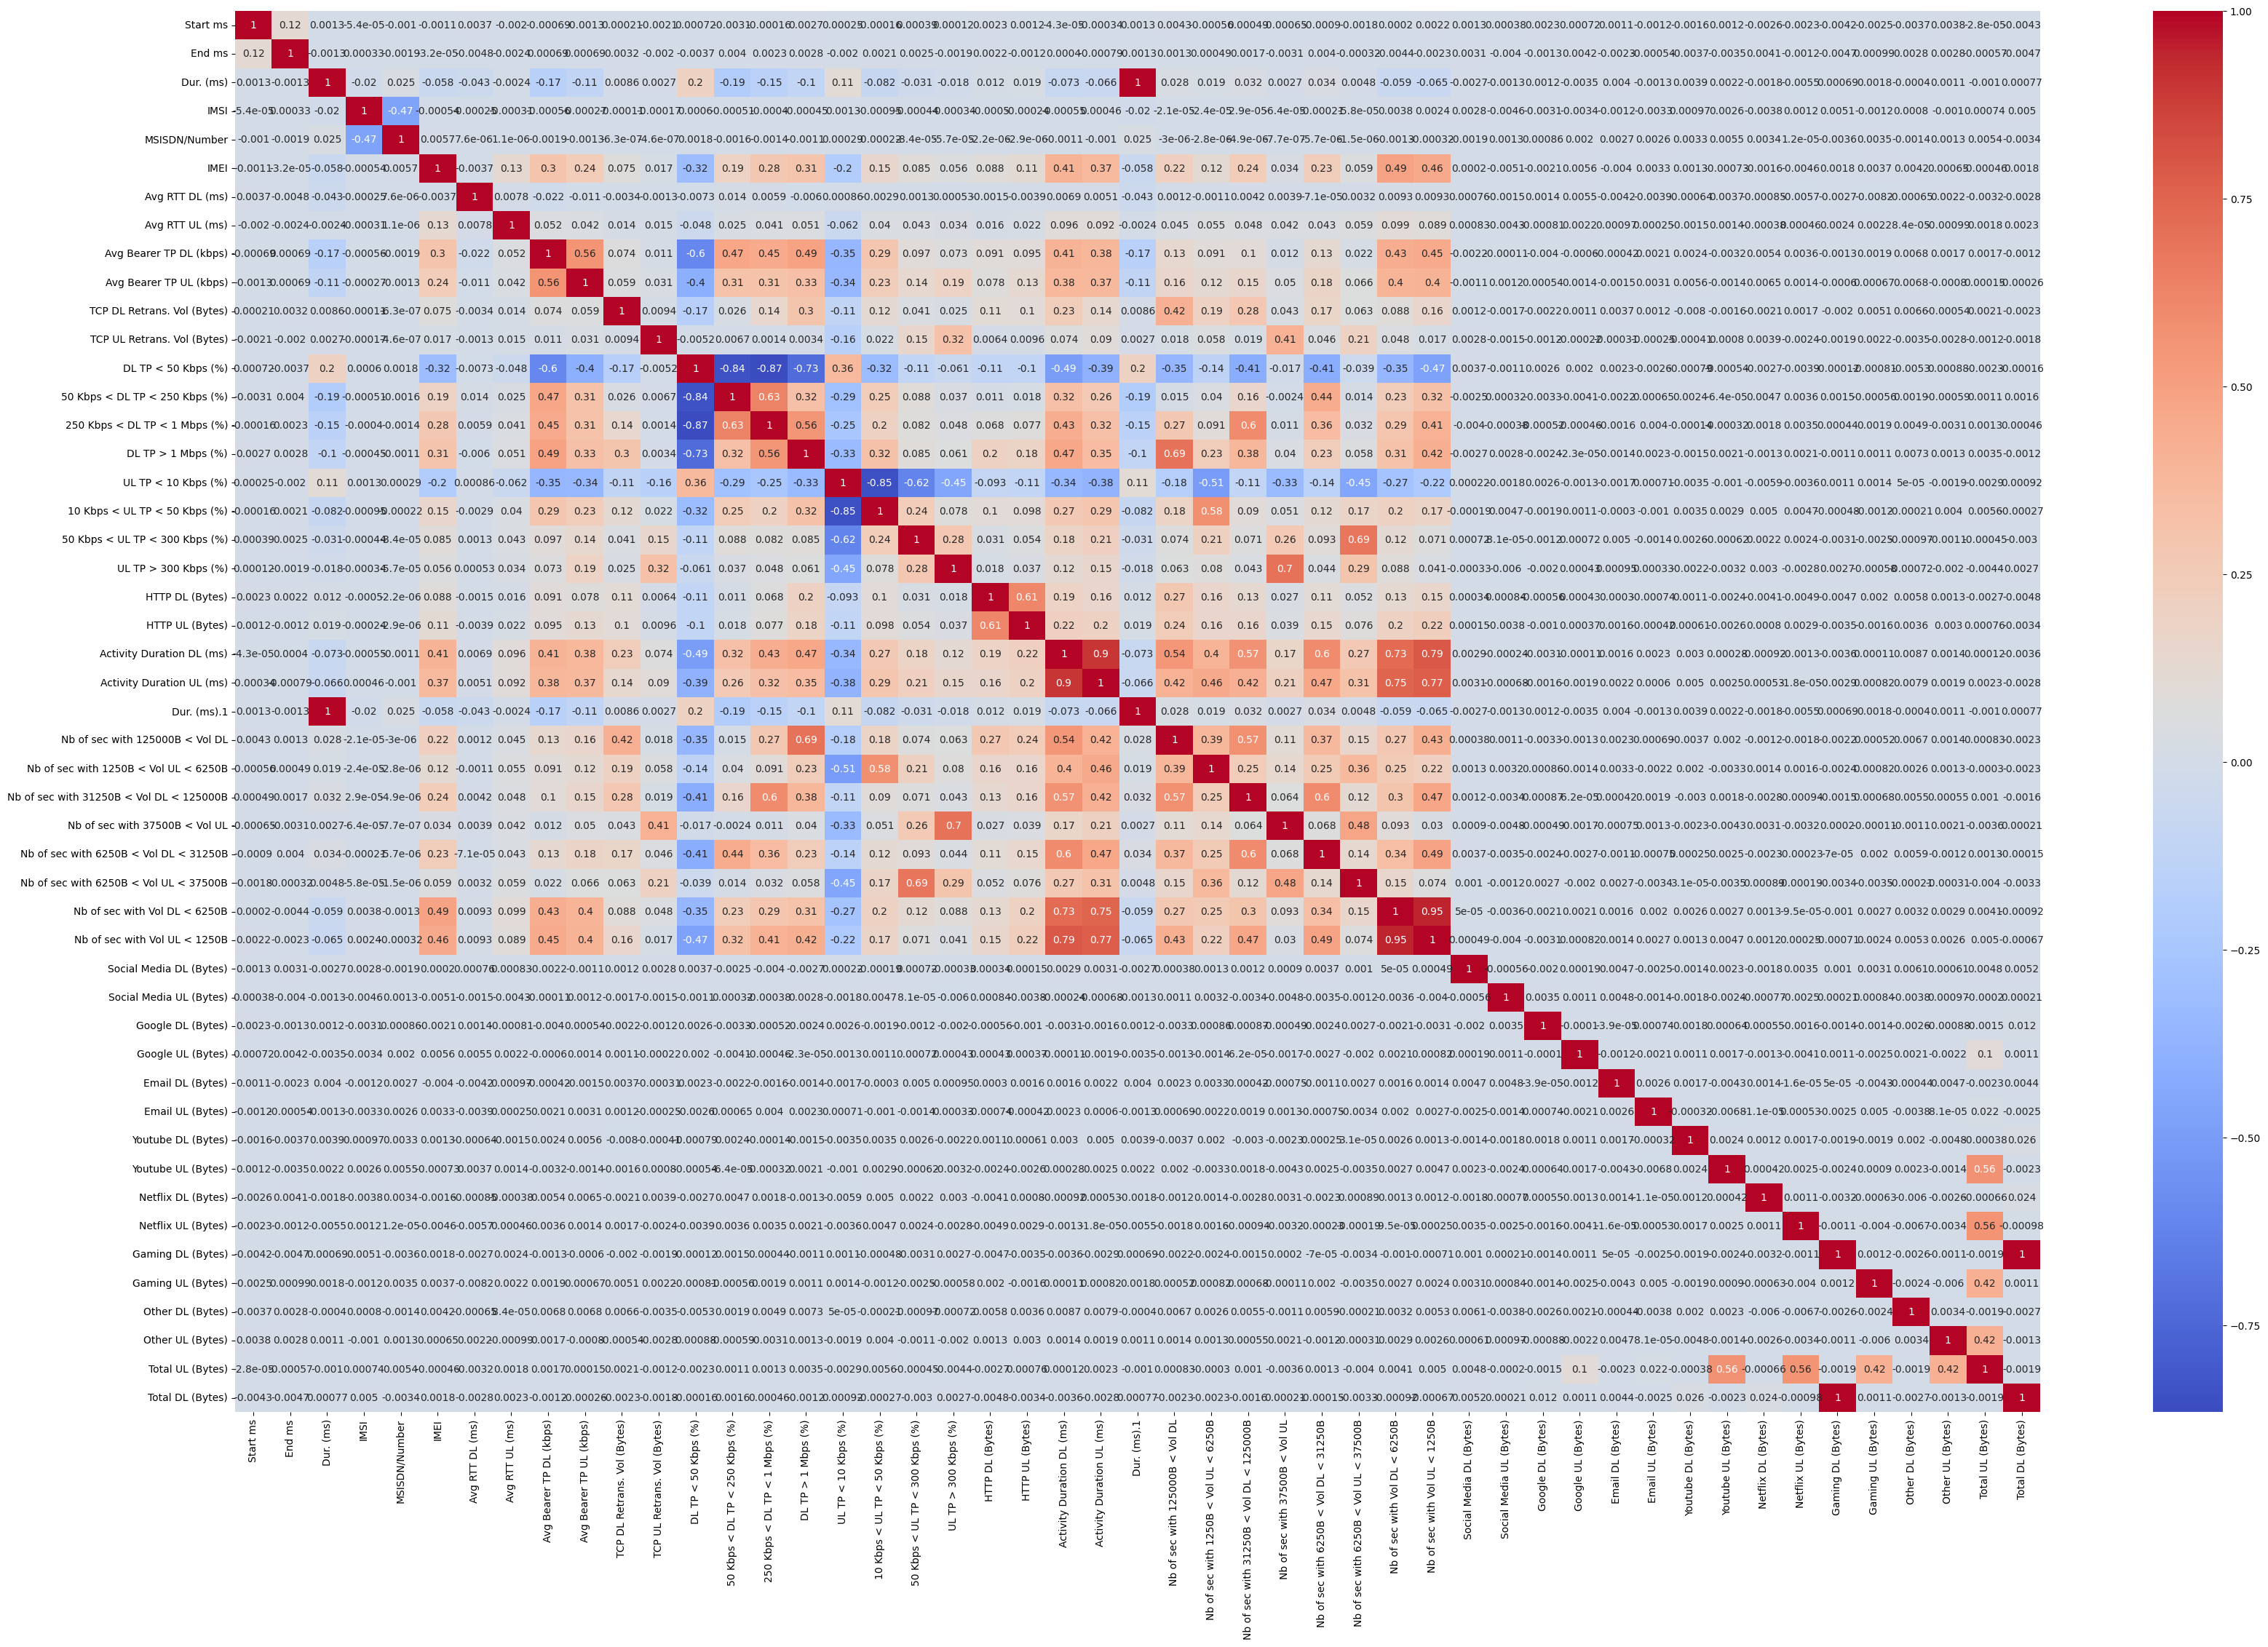

In [ ]:
plt.figure(figsize=(40,25))
sns.heatmap(df.select_dtypes(include=np.number).corr(),cmap='coolwarm',annot=True)

plt.show()

**Finding Skewness of the DataSet**

In [ ]:
# Calculate skewness for numerical features
skewness = df.select_dtypes(include=np.number).skew()
print(skewness)

Start ms                                      0.000968
End ms                                       -0.001163
Dur. (ms)                                     3.952622
IMSI                                         41.124164
MSISDN/Number                               333.342413
IMEI                                          1.073519
Avg RTT DL (ms)                              69.705161
Avg RTT UL (ms)                              31.530109
Avg Bearer TP DL (kbps)                       2.589445
Avg Bearer TP UL (kbps)                       4.503428
TCP DL Retrans. Vol (Bytes)                  24.840677
TCP UL Retrans. Vol (Bytes)                 141.035684
DL TP < 50 Kbps (%)                          -2.303600
50 Kbps < DL TP < 250 Kbps (%)                3.279706
250 Kbps < DL TP < 1 Mbps (%)                 4.577678
DL TP > 1 Mbps (%)                            5.383899
UL TP < 10 Kbps (%)                          -9.008830
10 Kbps < UL TP < 50 Kbps (%)                10.972894
50 Kbps < 

**Post Null Value Treatment, DataSet Description**

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Start,150000,2019-04-26 12:36:38.953740032,2019-04-04 12:01:18,2019-04-25 00:26:00.750000128,2019-04-26 08:51:24.500000,2019-04-27 18:18:59.750000128,2019-04-29 07:28:43,NaN
Start ms,150001.0,499.1882,0.0,250.0,499.0,749.0,999.0,288.610872
End,150000,2019-04-27 17:40:08.059673344,2019-04-24 22:59:58,2019-04-26 07:30:11.500000,2019-04-27 23:02:05,2019-04-29 07:15:07.500000,2019-04-30 23:59:27,NaN
End ms,150001.0,498.80088,0.0,251.0,500.0,750.0,999.0,288.096693
Dur. (ms),150001.0,104608.560347,7142.0,57442.0,86399.0,132430.0,1859336.0,81037.351353
IMSI,150001.0,208201639651669.0625,204047108489451.0,208201401264956.0,208201546359072.0,208201771607314.0,214074303349628.0,21447224608.895008
MSISDN/Number,150001.0,41882819545.027367,33601001722.0,33651508781.0,33663797508.0,33684730950.0,882397108489451.0,2438731270479.178223
IMEI,150001.0,48474547977654.554688,440015202000.0,35462609538986.0,35722409972293.0,86119704277453.0,99001201327774.0,22373590654759.304688
Avg RTT DL (ms),150001.0,109.795706,0.0,35.0,54.0,109.795706,96923.0,559.34262
Avg RTT UL (ms),150001.0,17.662883,0.0,3.0,7.0,17.662883,7120.0,76.529933


**The top 10 handsets used by the customers**

In [ ]:

top_10_handsets = df['Handset Type'].value_counts().head(10)
print(top_10_handsets)

Handset Type
Huawei B528S-23A                20324
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64


**top 3 handset manufacturers**

In [18]:
top_3_handsets=df['Handset Manufacturer'].value_counts().head(3)
print(top_3_handsets)

Handset Manufacturer
Apple      60137
Samsung    40839
Huawei     34423
Name: count, dtype: int64


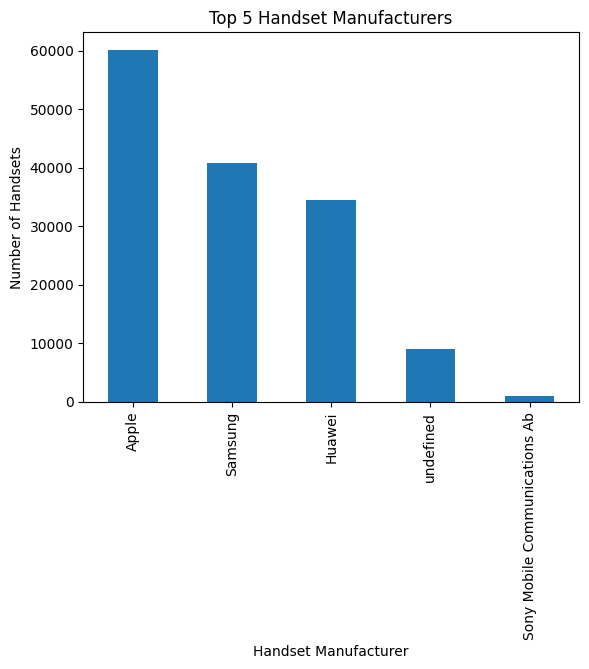

In [23]:
df['Handset Manufacturer'].value_counts().head(5).plot(kind='bar')
plt.xlabel('Handset Manufacturer')
plt.ylabel('Number of Handsets')
plt.title('Top 5 Handset Manufacturers')
plt.show()

In [ ]:
# prompt: top 5 handsets per top 3 handset manufacturer

# Group by Handset Manufacturer and then find the top 5 handsets for each manufacturer
top_5_handsets_per_manufacturer = df.groupby('Handset Manufacturer')['Handset Type'].value_counts().groupby(level=0).head(5)

# Filter for the top 3 handset manufacturers
top_3_manufacturers = df['Handset Manufacturer'].value_counts().head(3).index.tolist()
top_5_handsets_top_3_manufacturers = top_5_handsets_per_manufacturer[top_5_handsets_per_manufacturer.index.get_level_values('Handset Manufacturer').isin(top_3_manufacturers)]

print(top_5_handsets_top_3_manufacturers)

Handset Manufacturer  Handset Type                  
Apple                 Apple iPhone 6S (A1688)            9419
                      Apple iPhone 6 (A1586)             9023
                      Apple iPhone 7 (A1778)             6326
                      Apple iPhone Se (A1723)            5187
                      Apple iPhone 8 (A1905)             4993
Huawei                Huawei B528S-23A                  19752
                      Huawei E5180                       2079
                      Huawei P20 Lite Huawei Nova 3E     2021
                      Huawei P20                         1480
                      Huawei Y6 2018                      997
Samsung               Samsung Galaxy S8 (Sm-G950F)       4520
                      Samsung Galaxy A5 Sm-A520F         3724
                      Samsung Galaxy J5 (Sm-J530)        3696
                      Samsung Galaxy J3 (Sm-J330)        3484
                      Samsung Galaxy S7 (Sm-G930X)       3199
Name: count, dtyp

In [ ]:
df['Handset Manufacturer'].value_counts()

,count
Handset Manufacturer,
Apple,60137
Samsung,40839
Huawei,34423
undefined,8987
Sony Mobile Communications Ab,980
...,...
Pt. Arga Mas Lestari,1
Doke Communication (Hk) Limited,1
Vastking Technology (Hk) Limited,1


**Task 1.1- Your employer wants to have an overview of the users’ behavior on those  applications.
● Aggregate per user the following information in the column
 ○ numberof xDRsessions
 ○ Session duration
 ○ the total download (DL) and upload (UL) data
 ○ thetotal data volume (in Bytes) during this session for each application**

In [27]:
# prompt: use engagament on social media, YouTube,Netflix,Google,Email,Gaming,other both in Upload and download

# Assuming your DataFrame is named 'df' and it contains the necessary columns like 'Bearer Id', 'Dur. (ms)', 'Total DL (Bytes)', 'Total UL (Bytes)', 'Social Media DL (Bytes)', 'Social Media UL (Bytes)', etc.

# Group by 'Bearer Id' and aggregate the information for each user
user_behavior = df.groupby('Bearer Id').agg({
    'Dur. (ms)': 'sum',  # Total session duration per user
    'Total DL (Bytes)': 'sum',  # Total download data per user
    'Total UL (Bytes)': 'sum'  # Total upload data per user
}).reset_index()


# Create columns for social media, YouTube, Netflix, Google, Email, Gaming, and other applications
user_behavior['Social Media DL (Bytes)'] = df.groupby('Bearer Id')['Social Media DL (Bytes)'].sum()
user_behavior['Social Media UL (Bytes)'] = df.groupby('Bearer Id')['Social Media UL (Bytes)'].sum()
user_behavior['YouTube DL (Bytes)'] = df.groupby('Bearer Id')['Youtube DL (Bytes)'].sum()
user_behavior['YouTube UL (Bytes)'] = df.groupby('Bearer Id')['Youtube UL (Bytes)'].sum()
user_behavior['Netflix DL (Bytes)'] = df.groupby('Bearer Id')['Netflix DL (Bytes)'].sum()
user_behavior['Netflix UL (Bytes)'] = df.groupby('Bearer Id')['Netflix UL (Bytes)'].sum()
user_behavior['Google DL (Bytes)'] = df.groupby('Bearer Id')['Google DL (Bytes)'].sum()
user_behavior['Google UL (Bytes)'] = df.groupby('Bearer Id')['Google UL (Bytes)'].sum()
user_behavior['Email DL (Bytes)'] = df.groupby('Bearer Id')['Email DL (Bytes)'].sum()
user_behavior['Email UL (Bytes)'] = df.groupby('Bearer Id')['Email UL (Bytes)'].sum()
user_behavior['Gaming DL (Bytes)'] = df.groupby('Bearer Id')['Gaming DL (Bytes)'].sum()
user_behavior['Gaming UL (Bytes)'] = df.groupby('Bearer Id')['Gaming UL (Bytes)'].sum()

# Calculate the total data volume (download + upload) for each application
# ...(Add similar lines for other applications as needed)


# You might need to handle cases where columns are missing.
# You can fill missing values with 0 or use a more appropriate method.

# Now 'user_behavior' DataFrame contains the aggregated information per user.

print(user_behavior)


                   Bearer Id     Dur. (ms)  Total DL (Bytes)  \
0        6917537518543529984  2.453400e+04      5.007220e+08   
1        6917537604825860096  2.148900e+04      7.095493e+08   
2        6917537608536819712  2.778600e+04      8.544659e+08   
3        6917537633966310400  1.563500e+04      8.257865e+08   
4        6917537638622189568  2.426400e+04      6.249578e+08   
...                      ...           ...               ...   
134704  13186541164985800704  1.452910e+05      3.870016e+08   
134705  13186541166737199104  8.639900e+04      8.726888e+08   
134706  13186541166776899584  8.639900e+04      3.863551e+08   
134707  13186541167134199808  1.031130e+05      3.272128e+08   
134708                        5.037679e+07      4.437555e+11   

        Total UL (Bytes)  Social Media DL (Bytes)  Social Media UL (Bytes)  \
0           4.170461e+07                      NaN                      NaN   
1           3.869360e+07                      NaN                      NaN 

In [44]:
# prompt: numberof xDRsessions per user and sort them on descending order

# Assuming 'df' is your DataFrame

# Group by 'Bearer Id' and count the number of xDR sessions for each user
xDR_sessions_per_user = df.groupby('Bearer Id')['Dur. (ms)'].count().reset_index(name='Number of xDR Sessions')

# Sort the results in descending order of the number of xDR sessions
xDR_sessions_per_user = xDR_sessions_per_user.sort_values('Number of xDR Sessions', ascending=False)

print(xDR_sessions_per_user)

                   Bearer Id  Number of xDR Sessions
134708                                           991
103378  13042425979269199872                      16
88125   13042425965944199168                      10
103736  13042425981873399808                       9
93908   13042425972278300672                       9
...                      ...                     ...
45507    7349883251186700288                       1
45506    7349883251186629632                       1
45505    7349883251186599936                       1
45504    7349883251186589696                       1
67354    7349883261406010368                       1

[134709 rows x 2 columns]


In [47]:
df.loc[134708]

,134708
Bearer Id,13114483572136300544
Start,2019-04-28 21:42:46
Start ms,390.0
End,2019-04-30 06:39:18
End ms,77.0
Dur. (ms),118591.0
IMSI,208201402048001.0
MSISDN/Number,33609984109.0
IMEI,35202407829217.0
Last Location Name,T88492A


In [29]:
# prompt: Session Duration per user

# Calculate session duration per user
session_duration_per_user = df.groupby('MSISDN/Number')['Dur. (ms)'].sum().reset_index(name='Total Session Duration')

# Print the results
print(session_duration_per_user)

        MSISDN/Number  Total Session Duration
0        3.360100e+10            1.167200e+05
1        3.360100e+10            1.812300e+05
2        3.360100e+10            1.349690e+05
3        3.360101e+10            4.987800e+04
4        3.360101e+10            3.710400e+04
...               ...                     ...
106852   3.379000e+10            1.409880e+05
106853   4.188282e+10            7.255100e+07
106854   3.197021e+12            8.773850e+05
106855   3.370000e+14            2.530300e+05
106856   8.823971e+14            8.698440e+05

[106857 rows x 2 columns]


In [30]:
# prompt: thetotal download (DL) and upload (UL) data per user

# Calculate the total download (DL) and upload (UL) data per user
total_dl_ul_per_user = df.groupby('Bearer Id').agg({
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum'
}).reset_index()

# Print the results
print(total_dl_ul_per_user)

                   Bearer Id  Total DL (Bytes)  Total UL (Bytes)
0        6917537518543529984      5.007220e+08      4.170461e+07
1        6917537604825860096      7.095493e+08      3.869360e+07
2        6917537608536819712      8.544659e+08      1.554893e+07
3        6917537633966310400      8.257865e+08      4.960569e+07
4        6917537638622189568      6.249578e+08      2.198346e+07
...                      ...               ...               ...
134704  13186541164985800704      3.870016e+08      3.618959e+07
134705  13186541166737199104      8.726888e+08      3.591946e+07
134706  13186541166776899584      3.863551e+08      4.087768e+07
134707  13186541167134199808      3.272128e+08      4.614756e+07
134708                            4.437555e+11      4.057298e+10

[134709 rows x 3 columns]


In [31]:
# prompt: thetotal data volume (in Bytes) during this session for Social Media, YouTube, Netflix, Google, Email, Gaming, other . Each find it separately

# Calculate the total data volume (download + upload) for each application
user_behavior['Social Media Total (Bytes)'] = user_behavior['Social Media DL (Bytes)'] + user_behavior['Social Media UL (Bytes)']
user_behavior['YouTube Total (Bytes)'] = user_behavior['YouTube DL (Bytes)'] + user_behavior['YouTube UL (Bytes)']
user_behavior['Netflix Total (Bytes)'] = user_behavior['Netflix DL (Bytes)'] + user_behavior['Netflix UL (Bytes)']
user_behavior['Google Total (Bytes)'] = user_behavior['Google DL (Bytes)'] + user_behavior['Google UL (Bytes)']
user_behavior['Email Total (Bytes)'] = user_behavior['Email DL (Bytes)'] + user_behavior['Email UL (Bytes)']
user_behavior['Gaming Total (Bytes)'] = user_behavior['Gaming DL (Bytes)'] + user_behavior['Gaming UL (Bytes)']

# Calculate the total data volume for "other" applications (you might need to define this based on your data)
other_dl_bytes = df['Total DL (Bytes)'].sum() - (user_behavior['Social Media DL (Bytes)'].sum() + user_behavior['YouTube DL (Bytes)'].sum() + user_behavior['Netflix DL (Bytes)'].sum() + user_behavior['Google DL (Bytes)'].sum() + user_behavior['Email DL (Bytes)'].sum() + user_behavior['Gaming DL (Bytes)'].sum())
other_ul_bytes = df['Total UL (Bytes)'].sum() - (user_behavior['Social Media UL (Bytes)'].sum() + user_behavior['YouTube UL (Bytes)'].sum() + user_behavior['Netflix UL (Bytes)'].sum() + user_behavior['Google UL (Bytes)'].sum() + user_behavior['Email UL (Bytes)'].sum() + user_behavior['Gaming UL (Bytes)'].sum())
user_behavior['Other Total (Bytes)'] = other_dl_bytes + other_ul_bytes

# Print the total data volume for each application
print("Total Data Volume for Social Media:", user_behavior['Social Media Total (Bytes)'].sum())
print("Total Data Volume for YouTube:", user_behavior['YouTube Total (Bytes)'].sum())
print("Total Data Volume for Netflix:", user_behavior['Netflix Total (Bytes)'].sum())
print("Total Data Volume for Google:", user_behavior['Google Total (Bytes)'].sum())
print("Total Data Volume for Email:", user_behavior['Email Total (Bytes)'].sum())
print("Total Data Volume for Gaming:", user_behavior['Gaming Total (Bytes)'].sum())
print("Total Data Volume for Other:", user_behavior['Other Total (Bytes)'].sum())

Total Data Volume for Social Media: 0.0
Total Data Volume for YouTube: 0.0
Total Data Volume for Netflix: 0.0
Total Data Volume for Google: 0.0
Total Data Volume for Email: 0.0
Total Data Volume for Gaming: 0.0
Total Data Volume for Other: 1.001766054409504e+19


In [37]:
# prompt: thetotal data volume (in Bytes) , upload and download separately for each Bearer on  YouTube  and sort the Bearer descending order based on total data volume

# Calculate the total data volume (download + upload) for YouTube for each Bearer ID
user_behavior['YouTube Total (Bytes)'] = user_behavior['YouTube DL (Bytes)'] + user_behavior['YouTube UL (Bytes)']

# Create a new DataFrame with only the Bearer ID and YouTube Total data volume
youtube_data = user_behavior[['Bearer Id', 'YouTube Total (Bytes)']].copy()

# Sort the DataFrame in descending order based on the YouTube Total data volume
youtube_data_sorted = youtube_data.sort_values('YouTube Total (Bytes)', ascending=False)

# Display the sorted DataFrame
print(youtube_data_sorted)

# You can further process this data to get the upload and download volumes separately
# if you need that level of detail.

                   Bearer Id  YouTube Download (Bytes)  \
0        6917537518543529984              6.139644e+06   
1        6917537604825860096              1.028122e+07   
2        6917537608536819712              5.385159e+06   
3        6917537633966310400              1.234702e+07   
4        6917537638622189568              1.523182e+07   
...                      ...                       ...   
134704  13186541164985800704              2.214792e+07   
134705  13186541166737199104              1.187906e+07   
134706  13186541166776899584              2.216380e+07   
134707  13186541167134199808              1.209932e+07   
134708                                    1.169394e+10   

        YouTube Upload (Bytes)  YouTube Total (Bytes)  
0                 2.071526e+06           8.211170e+06  
1                 1.811998e+07           2.840120e+07  
2                 4.295851e+06           9.681010e+06  
3                 1.108953e+07           2.343655e+07  
4                 8.401